# DDPM em Fashion-MNIST: avaliação e criação de dataset

Este notebook aplica ao Fashion-MNIST o objetivo de predição de ruído e a amostragem de **Denoising Diffusion Probabilistic Models**. Além das perdas de treino e validação, avaliamos as imagens por meio de um classificador Fashion-MNIST: KID em embeddings, confiança, cobertura e entropia de classes, diversidade, distância ao vizinho real mais próximo e distribuição de pixels.

> As métricas baseadas no classificador são adequadas para comparar execuções deste notebook, mas não equivalem ao Inception Score/FID dos artigos.

## 1. Ambiente e diretórios

Todos os downloads, modelos, imagens geradas, manifestos e métricas ficam em `seminar_1/data/fashion_mnist`.

In [1]:
import csv
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
from torchvision.io import read_image
from torchvision.utils import make_grid, save_image

SEED = 42
QUICK_RUN = False
REGENERATE = False
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 1_000
EPOCHS = 20 if QUICK_RUN else 50
CLASSIFIER_EPOCHS = 5 if QUICK_RUN else 10
TRAIN_SAMPLES = 10_000 if QUICK_RUN else 50_000
VALID_SAMPLES = 2_000 if QUICK_RUN else 10_000
GENERATED_COUNT = 1_000 if QUICK_RUN else 10_000
EVALUATION_COUNT = min(1_000, VALID_SAMPLES, GENERATED_COUNT)
BATCH_SIZE = 128

ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = ROOT / "seminar_1" / "data" / "fashion_mnist"
SOURCE_DIR = DATA_ROOT / "source"
MODEL_DIR = DATA_ROOT / "models"
GENERATED_DIR = DATA_ROOT / f"generated_{GENERATED_COUNT}"
METRICS_DIR = DATA_ROOT / "metrics"
for directory in (SOURCE_DIR, MODEL_DIR, GENERATED_DIR, METRICS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
DDPM_CHECKPOINT = MODEL_DIR / f"ddpm_{TRAIN_SAMPLES}_{EPOCHS}.pt"
CLASSIFIER_CHECKPOINT = MODEL_DIR / f"classifier_{TRAIN_SAMPLES}_{CLASSIFIER_EPOCHS}.pt"
print(f"device={DEVICE}, treino={TRAIN_SAMPLES}, geradas={GENERATED_COUNT}")

device=cpu, treino=50000, geradas=10000


## 2. Fashion-MNIST

A divisão treino/validação é determinística. As imagens são normalizadas para $[-1,1]$.

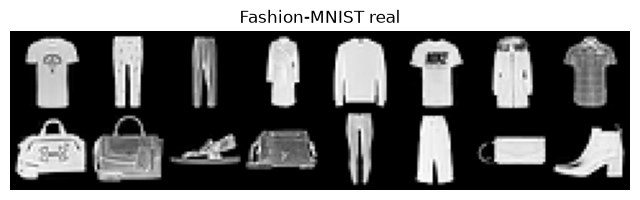

In [2]:
CLASS_NAMES = ["camiseta", "calça", "pulôver", "vestido", "casaco", "sandália", "camisa", "tênis", "bolsa", "bota"]
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_train = datasets.FashionMNIST(SOURCE_DIR, train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(SOURCE_DIR, train=False, download=True, transform=transform)
permutation = torch.randperm(len(full_train), generator=torch.Generator().manual_seed(SEED))
train_data = Subset(full_train, permutation[:TRAIN_SAMPLES])
valid_data = Subset(full_train, permutation[TRAIN_SAMPLES:TRAIN_SAMPLES + VALID_SAMPLES])
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
grid = make_grid((images[:16] + 1) / 2, nrow=8)
plt.figure(figsize=(8, 2.5))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Fashion-MNIST real")
plt.show()

## 3. Processo de difusão e rede

Treinamos $\epsilon_\theta(x_t,t)$ com o objetivo simplificado $\mathbb{E}\lVert\epsilon-\epsilon_\theta(x_t,t)\rVert^2$.

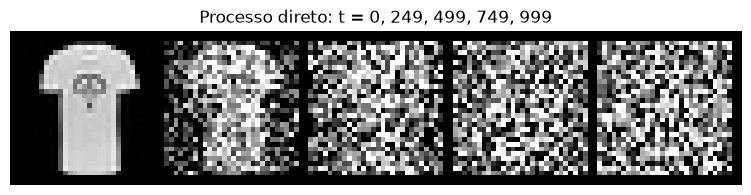

In [3]:
betas = torch.linspace(1e-4, 2e-2, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_previous = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
posterior_variance = betas * (1 - alpha_bars_previous) / (1 - alpha_bars)

def extract(values, timesteps, shape):
    return values[timesteps].view(timesteps.shape[0], *((1,) * (len(shape) - 1)))

def q_sample(x0, timesteps, noise=None):
    noise = torch.randn_like(x0) if noise is None else noise
    mean = extract(alpha_bars.sqrt(), timesteps, x0.shape) * x0
    std = extract((1 - alpha_bars).sqrt(), timesteps, x0.shape)
    return mean + std * noise, noise

assert torch.all(alpha_bars[1:] < alpha_bars[:-1]) and alpha_bars[-1] < 1e-4
steps = torch.tensor([0, 249, 499, 749, 999], device=DEVICE)
noisy, _ = q_sample(images[:1].to(DEVICE).repeat(5, 1, 1, 1), steps)
grid = make_grid((noisy.cpu() + 1) / 2, nrow=5)
plt.figure(figsize=(10, 2))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Processo direto: t = 0, 249, 499, 749, 999")
plt.show()

In [4]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, size=32):
        super().__init__()
        half = size // 2
        self.register_buffer("frequencies", torch.exp(-math.log(10_000) * torch.arange(half) / (half - 1)))

    def forward(self, timesteps):
        angles = timesteps[:, None].float() * self.frequencies[None]
        return torch.cat((angles.sin(), angles.cos()), dim=1)

class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTimeEmbedding(), nn.Linear(32, 64), nn.SiLU())
        self.time1, self.time2, self.time3 = nn.Linear(64, 32), nn.Linear(64, 64), nn.Linear(64, 64)
        self.down1 = nn.Conv2d(1, 32, 3, padding=1)
        self.down2 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.down3 = nn.Conv2d(64, 64, 4, stride=2, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.output = nn.Conv2d(32, 1, 3, padding=1)
        self.norm1, self.norm5 = nn.GroupNorm(8, 32), nn.GroupNorm(8, 32)
        self.norm2, self.norm3, self.norm4 = nn.GroupNorm(8, 64), nn.GroupNorm(8, 64), nn.GroupNorm(8, 64)

    def forward(self, x, timesteps):
        embedding = self.time(timesteps)
        h1 = F.silu(self.norm1(self.down1(x) + self.time1(embedding)[:, :, None, None]))
        h2 = F.silu(self.norm2(self.down2(h1) + self.time2(embedding)[:, :, None, None]))
        h3 = F.silu(self.norm3(self.down3(h2) + self.time3(embedding)[:, :, None, None]))
        h = F.silu(self.norm4(self.up1(h3) + h2))
        h = F.silu(self.norm5(self.up2(h) + h1))
        return self.output(h)

model = TinyDenoiser().to(DEVICE)
assert model(torch.zeros(2, 1, 28, 28, device=DEVICE), torch.tensor([0, T - 1], device=DEVICE)).shape == (2, 1, 28, 28)
print(f"{sum(p.numel() for p in model.parameters()):,} parâmetros")

210,465 parâmetros


## 4. Treino e validação do DDPM

época 01/50: treino=0.1778, validação=0.0844
época 02/50: treino=0.0775, validação=0.0723
época 03/50: treino=0.0691, validação=0.0667
época 04/50: treino=0.0635, validação=0.0623
época 05/50: treino=0.0605, validação=0.0611
época 06/50: treino=0.0592, validação=0.0587
época 07/50: treino=0.0567, validação=0.0562
época 08/50: treino=0.0568, validação=0.0546
época 09/50: treino=0.0547, validação=0.0549
época 10/50: treino=0.0542, validação=0.0536
época 11/50: treino=0.0543, validação=0.0550
época 12/50: treino=0.0532, validação=0.0530
época 13/50: treino=0.0533, validação=0.0525
época 14/50: treino=0.0520, validação=0.0531
época 15/50: treino=0.0524, validação=0.0525
época 16/50: treino=0.0521, validação=0.0522
época 17/50: treino=0.0502, validação=0.0514
época 18/50: treino=0.0508, validação=0.0515
época 19/50: treino=0.0499, validação=0.0510
época 20/50: treino=0.0501, validação=0.0522
época 21/50: treino=0.0499, validação=0.0495
época 22/50: treino=0.0497, validação=0.0485
época 23/5

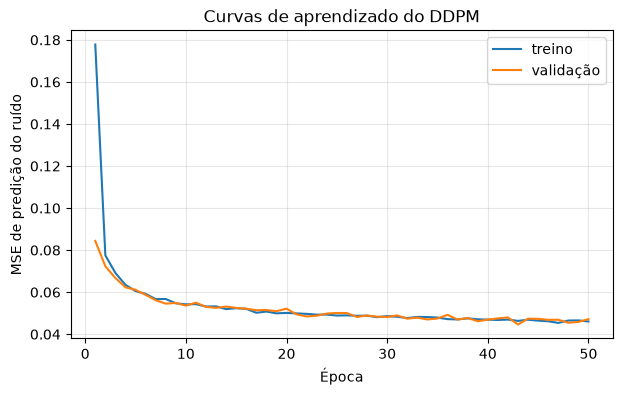

In [5]:
def diffusion_loss(batch, training):
    x0 = batch.to(DEVICE)
    timesteps = torch.randint(T, (x0.shape[0],), device=DEVICE)
    xt, noise = q_sample(x0, timesteps)
    with torch.set_grad_enabled(training):
        return F.mse_loss(model(xt, timesteps), noise)

if DDPM_CHECKPOINT.exists():
    checkpoint = torch.load(DDPM_CHECKPOINT, map_location=DEVICE, weights_only=True)
    model.load_state_dict(checkpoint["model"])
    train_losses, valid_losses = checkpoint["train_losses"], checkpoint["valid_losses"]
    print(f"Checkpoint carregado: {DDPM_CHECKPOINT}")
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
    train_losses, valid_losses = [], []
    for epoch in range(EPOCHS):
        model.train()
        train_total = 0.0
        for x0, _ in train_loader:
            loss = diffusion_loss(x0, training=True)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            train_total += loss.item() * x0.shape[0]
        model.eval()
        valid_total = sum(diffusion_loss(x0, training=False).item() * x0.shape[0] for x0, _ in valid_loader)
        train_losses.append(train_total / len(train_data))
        valid_losses.append(valid_total / len(valid_data))
        print(f"época {epoch + 1:02d}/{EPOCHS}: treino={train_losses[-1]:.4f}, validação={valid_losses[-1]:.4f}")
    torch.save({"model": model.state_dict(), "train_losses": train_losses, "valid_losses": valid_losses}, DDPM_CHECKPOINT)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="treino")
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label="validação")
plt.xlabel("Época")
plt.ylabel("MSE de predição do ruído")
plt.title("Curvas de aprendizado do DDPM")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 5. Classificador usado como avaliador

O classificador não participa do treino do DDPM. Seus embeddings permitem medir qualidade e diversidade sem baixar outro modelo.

In [6]:
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
        )
        self.output = nn.Linear(128, 10)

    def forward(self, x, return_features=False):
        features = self.features(x)
        logits = self.output(features)
        return (logits, features) if return_features else logits

classifier = FashionClassifier().to(DEVICE)
if CLASSIFIER_CHECKPOINT.exists():
    classifier.load_state_dict(torch.load(CLASSIFIER_CHECKPOINT, map_location=DEVICE, weights_only=True))
else:
    optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    for epoch in range(CLASSIFIER_EPOCHS):
        classifier.train()
        correct = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = classifier(x)
            loss = F.cross_entropy(logits, y)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.numel()
        print(f"classificador {epoch + 1:02d}/{CLASSIFIER_EPOCHS}: acurácia treino={correct / total:.3f}")
    torch.save(classifier.state_dict(), CLASSIFIER_CHECKPOINT)

classifier.eval()
test_correct = test_total = 0
with torch.inference_mode():
    for x, y in test_loader:
        predictions = classifier(x.to(DEVICE)).argmax(1).cpu()
        test_correct += (predictions == y).sum().item()
        test_total += y.numel()
classifier_accuracy = test_correct / test_total
print(f"Acurácia do avaliador no teste: {classifier_accuracy:.3%}")

classificador 01/10: acurácia treino=0.821
classificador 02/10: acurácia treino=0.883
classificador 03/10: acurácia treino=0.901
classificador 04/10: acurácia treino=0.914
classificador 05/10: acurácia treino=0.923
classificador 06/10: acurácia treino=0.932
classificador 07/10: acurácia treino=0.938
classificador 08/10: acurácia treino=0.945
classificador 09/10: acurácia treino=0.950
classificador 10/10: acurácia treino=0.957
Acurácia do avaliador no teste: 91.590%


## 6. Geração e persistência do novo dataset

Cada PNG recebe um rótulo previsto e uma confiança no `manifest.csv`. Esses são **pseudorrótulos**, não verdades de referência.

In [7]:
@torch.inference_mode()
def sample_ddpm(sample_count):
    model.eval()
    x = torch.randn(sample_count, 1, 28, 28, device=DEVICE)
    for step in reversed(range(T)):
        timesteps = torch.full((sample_count,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        mean = (x - betas[step] / torch.sqrt(1 - alpha_bars[step]) * predicted_noise) / torch.sqrt(alphas[step])
        x = mean + posterior_variance[step].sqrt() * torch.randn_like(x) if step > 0 else mean
    return x.clamp(-1, 1).cpu()

existing_images = sorted(GENERATED_DIR.glob("fashion_*.png"))
if not REGENERATE and len(existing_images) == GENERATED_COUNT:
    generated_images = torch.stack([read_image(path)[:1].float() / 127.5 - 1 for path in existing_images])
    previous_metrics_path = METRICS_DIR / "metrics.json"
    previous_metrics = json.loads(previous_metrics_path.read_text()) if previous_metrics_path.exists() else {}
    generation_seconds = previous_metrics.get("generation_seconds", float("nan"))
    print(f"Dataset existente carregado de {GENERATED_DIR}")
else:
    generated_batches = []
    generation_start = time.perf_counter()
    for start_index in range(0, GENERATED_COUNT, BATCH_SIZE):
        generated_batches.append(sample_ddpm(min(BATCH_SIZE, GENERATED_COUNT - start_index)))
    generated_images = torch.cat(generated_batches)
    generation_seconds = time.perf_counter() - generation_start

classifier.eval()
with torch.inference_mode():
    probabilities = classifier(generated_images.to(DEVICE)).softmax(1).cpu()
confidences, predicted_labels = probabilities.max(1)
manifest_path = GENERATED_DIR / "manifest.csv"
with manifest_path.open("w", newline="", encoding="utf-8") as manifest_file:
    writer = csv.writer(manifest_file)
    writer.writerow(["filename", "predicted_label", "class_name", "confidence", "sampler", "steps"])
    for index, (image, label, confidence) in enumerate(zip(generated_images, predicted_labels, confidences)):
        filename = f"fashion_{index:05d}.png"
        save_image((image + 1) / 2, GENERATED_DIR / filename)
        writer.writerow([filename, label.item(), CLASS_NAMES[label], f"{confidence.item():.6f}", "DDPM", T])
print(f"Dataset: {len(generated_images)} imagens em {GENERATED_DIR}")
print(f"Geração: {generation_seconds:.2f} s ({len(generated_images) / generation_seconds:.1f} imagens/s)")

Dataset: 10000 imagens em /home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_1/data/fashion_mnist/generated_10000
Geração: 1505.29 s (6.6 imagens/s)


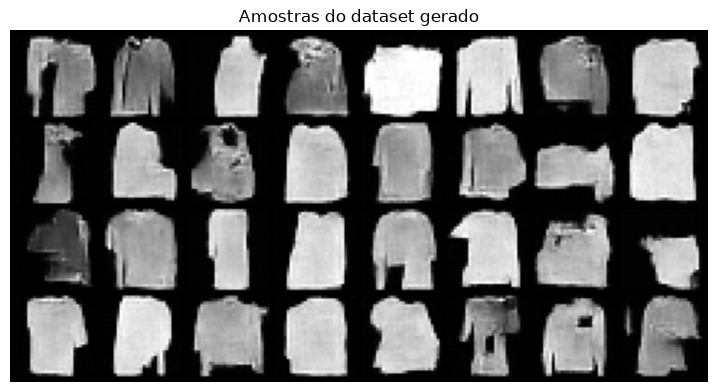

In [8]:
grid = make_grid((generated_images[:32] + 1) / 2, nrow=8)
plt.figure(figsize=(9, 5))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Amostras do dataset gerado")
plt.show()

## 7. Métricas de qualidade e diversidade

O KID abaixo usa o kernel polinomial nos embeddings do classificador local. Valores menores indicam distribuições mais próximas. A distância ao vizinho real ajuda a detectar cópia; diversidade e entropia baixas sugerem colapso de modos.

In [9]:
@torch.inference_mode()
def collect_features(loader, limit):
    feature_parts, image_parts, label_parts = [], [], []
    for x, y in loader:
        _, features = classifier(x.to(DEVICE), return_features=True)
        feature_parts.append(features.cpu())
        image_parts.append(x)
        label_parts.append(y)
        if sum(len(part) for part in feature_parts) >= limit:
            break
    return torch.cat(feature_parts)[:limit], torch.cat(image_parts)[:limit], torch.cat(label_parts)[:limit]

def kernel_inception_distance(real_features, fake_features):
    real, fake = real_features.double(), fake_features.double()
    dimension = real.shape[1]
    k_rr = (real @ real.T / dimension + 1).pow(3)
    k_ff = (fake @ fake.T / dimension + 1).pow(3)
    k_rf = (real @ fake.T / dimension + 1).pow(3)
    n, m = len(real), len(fake)
    return ((k_rr.sum() - k_rr.diagonal().sum()) / (n * (n - 1)) + (k_ff.sum() - k_ff.diagonal().sum()) / (m * (m - 1)) - 2 * k_rf.mean()).item()

real_features, real_images, real_labels = collect_features(test_loader, EVALUATION_COUNT)
with torch.inference_mode():
    _, generated_features = classifier(generated_images[:EVALUATION_COUNT].to(DEVICE), return_features=True)
generated_features = generated_features.cpu()
pairwise_to_real = torch.cdist(generated_features, real_features)
nearest_distances = pairwise_to_real.min(1).values
class_counts = torch.bincount(predicted_labels, minlength=10)
class_probabilities = class_counts / class_counts.sum()
normalized_entropy = (-(class_probabilities[class_probabilities > 0] * class_probabilities[class_probabilities > 0].log()).sum() / math.log(10)).item()
real_histogram = torch.histc(real_images, bins=50, min=-1, max=1)
generated_histogram = torch.histc(generated_images[:EVALUATION_COUNT], bins=50, min=-1, max=1)
pixel_total_variation = (0.5 * (real_histogram / real_histogram.sum() - generated_histogram / generated_histogram.sum()).abs().sum()).item()

metrics = {
    "ddpm_train_mse": train_losses[-1],
    "ddpm_validation_mse": valid_losses[-1],
    "evaluator_test_accuracy": classifier_accuracy,
    "embedding_kid": kernel_inception_distance(real_features, generated_features),
    "mean_classifier_confidence": confidences.mean().item(),
    "class_coverage": int((class_counts > 0).sum()),
    "normalized_class_entropy": normalized_entropy,
    "embedding_diversity": torch.pdist(generated_features).mean().item(),
    "nearest_real_embedding_distance": nearest_distances.mean().item(),
    "pixel_histogram_total_variation": pixel_total_variation,
    "generation_seconds": generation_seconds,
    "images_per_second": len(generated_images) / generation_seconds,
}
with (METRICS_DIR / "metrics.json").open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics, metrics_file, indent=2, ensure_ascii=False)
for name, value in metrics.items():
    print(f"{name}: {value:.6g}")

ddpm_train_mse: 0.0460739
ddpm_validation_mse: 0.0471818
evaluator_test_accuracy: 0.9159
embedding_kid: 77.1681
mean_classifier_confidence: 0.692488
class_coverage: 10
normalized_class_entropy: 0.829656
embedding_diversity: 18.5229
nearest_real_embedding_distance: 12.3658
pixel_histogram_total_variation: 0.229759
generation_seconds: 1505.29
images_per_second: 6.64322


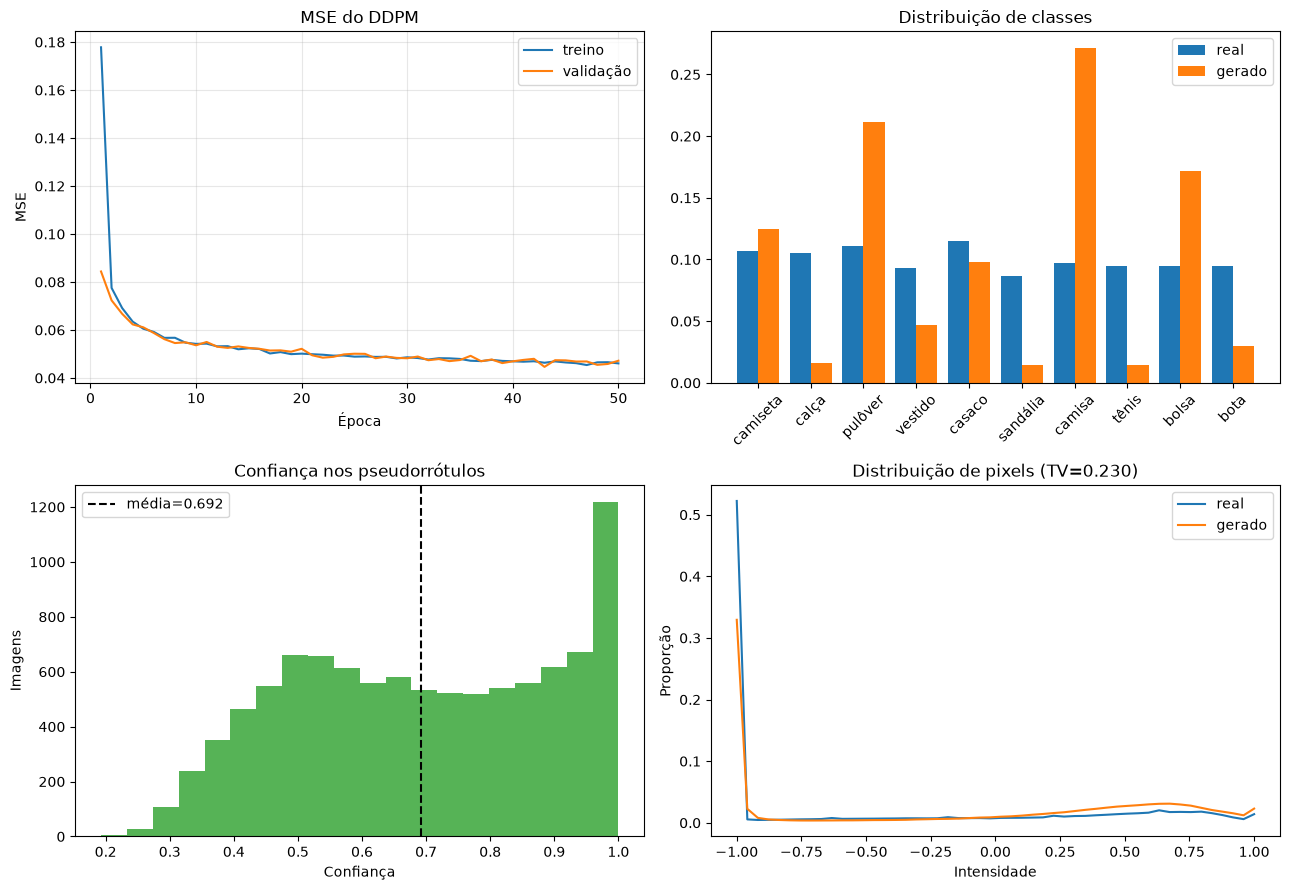

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(range(1, len(train_losses) + 1), train_losses, label="treino")
axes[0, 0].plot(range(1, len(valid_losses) + 1), valid_losses, label="validação")
axes[0, 0].set(title="MSE do DDPM", xlabel="Época", ylabel="MSE")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

real_counts = torch.bincount(real_labels, minlength=10) / len(real_labels)
positions = np.arange(10)
axes[0, 1].bar(positions - 0.2, real_counts, width=0.4, label="real")
axes[0, 1].bar(positions + 0.2, class_probabilities, width=0.4, label="gerado")
axes[0, 1].set(title="Distribuição de classes", xticks=positions, xticklabels=CLASS_NAMES)
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].legend()

axes[1, 0].hist(confidences.numpy(), bins=20, color="tab:green", alpha=0.8)
axes[1, 0].axvline(confidences.mean(), color="black", linestyle="--", label=f"média={confidences.mean():.3f}")
axes[1, 0].set(title="Confiança nos pseudorrótulos", xlabel="Confiança", ylabel="Imagens")
axes[1, 0].legend()

bins = torch.linspace(-1, 1, 50)
axes[1, 1].plot(bins, real_histogram / real_histogram.sum(), label="real")
axes[1, 1].plot(bins, generated_histogram / generated_histogram.sum(), label="gerado")
axes[1, 1].set(title=f"Distribuição de pixels (TV={pixel_total_variation:.3f})", xlabel="Intensidade", ylabel="Proporção")
axes[1, 1].legend()
plt.tight_layout()
plt.savefig(METRICS_DIR / "metric_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Como interpretar

- **MSE de validação** próxima à de treino indica que o preditor de ruído generaliza.
- **KID e distância ao vizinho real** devem ser comparados entre execuções com o mesmo avaliador e número de amostras.
- **Cobertura = 10** e entropia próxima de 1 indicam presença equilibrada das classes; não garantem qualidade visual.
- **Confiança** só é confiável porque a acurácia de teste do avaliador também é reportada.
- O `manifest.csv` torna o diretório de PNGs um dataset carregável, mantendo explícito que os rótulos são previstos.